# Judul dan identitas kelompok
Judul analisis yang spesifik:  Analisis Data Kualitas Udara Kota Pune
Nomor kelompok: 3
| Nama | NRP |
|------|-----|
| Muhammad Fathoni Rijalussyauqi | 5027261015 |
| Nicholas Gerard Rante | 5027261109 |
| Ardyssa Kanani Aritya Wijaya | 5027261136 |

Topik yang dipilih : Smartcity

# Latar belakang dan pertanyaan
Tulis satu paragraf tentang kenapa data ini menarik:
Kami memilih dataset ini dikarenakan secara sekilas terlihat beginner-friendly. Dan dapat dibayangkan secara intuisi terkait penggunaan data terhadap model yang akan dibuat.

lalu tuliskan 2–3 pertanyaan yang ingin kalian jawab dengan statistik deskriptif. Contoh:
1. Di mana area di Kota Pune dengan kualitas udara paling buruk?
2. Di [nama area dengan total polutan terbanyak secara median], polutan apa yang paling banyak?

In [6]:
# Memuat Data
import pandas as pd # Memuat library pandas

df = pd.read_csv("Pune_SmartCity_Test_Dataset.csv")  # Memuat dataset yang berbentuk csv
print(df.shape)   # (menampilkan jumlah baris dan jumlah kolom)

df.head() # Menampilkan 5 baris pertama pada dataset
# Jelaskan secara singkat: setiap baris mewakili apa? Satu hari? Satu URL? Satu server?
# ==> Setiap baris mewakili rekaman paramater AQI di 10 Area berbeda di kota Pune pada waktu tertentu.

(103205, 28)


,NAME,HUMIDITY,LIGHT,NO_MAX,NO_MIN,NO2_MAX,NO2_MIN,OZONE_MAX,OZONE_MIN,PM10_MAX,...,CO2_MIN,SOUND,TEMPRATURE_MAX,TEMPRATURE_MIN,UV_MAX,UV_MIN,AIR_PRESSURE,LASTUPDATEDATETIME,Lattitude,Longitude
0,BopadiSquare_65,19.995,3762.914,0,0,59.0,54.0,15.0,0.0,22.0,...,401.0,66.133,41.0,24.0,5.3,0.2,0.933,13/05/19 12:16,18.559427,73.828656
1,Karve Statue Square_5,20.730,529.245,0,0,82.0,77.0,18.0,0.0,23.0,...,374.0,63.568,39.0,25.0,0.8,0.1,0.930,13/05/19 12:16,18.501727,73.813595
2,Lullanagar_Square_14,17.387,693.375,0,0,74.0,63.0,25.0,0.0,25.0,...,0.0,59.362,40.0,24.0,0.5,0.2,0.926,13/05/19 12:16,18.487306,73.885650
3,Hadapsar_Gadital_01,18.725,723.631,0,0,110.0,105.0,5.0,0.0,26.0,...,427.0,72.178,38.0,26.0,1.3,0.1,0.930,13/05/19 12:16,18.501834,73.941478
4,PMPML_Bus_Depot_Deccan_15,20.622,816.476,0,0,93.0,85.0,9.0,0.0,20.0,...,26.0,74.756,40.0,25.0,NaN,NaN,0.932,13/05/19 12:16,18.451716,73.856170


*Deskripsi data dan kamus data*
# Sumber data beserta link dan lisensinya:
Kaggle https://www.kaggle.com/datasets/akshman/pune-smartcity-test-dataset

# Siapa yang mengumpulkan data, kapan, dan bagaimana (sesuai informasi dari sumbernya):
Data dikumpulkan oleh PSCDCL (Pune Smart City Development Corporation Limited) dan IISC (The Indian Institute of Science) pada tahun 2019

# Jumlah baris dan kolom:
(103205, 28)
Kamus data untuk semua kolom yang dipakai, dengan format seperti tabel di bawah

| Kolom | Arti | Jenis Variable | Skala | Satuan | Contoh |
|-------|------|----------------|-------|--------|--------|
| NAME | Nama area yang tercatat | Kualitatif | Nominal | - | Karve Statue Square_5	|
| HUMIDITY | Kelembapan di area tersebut | Kuantitatif Kontinu | Interval | Persen | 20.73 |
| TEMPRATURE | Suhu udara di area tersebut | Kuantitatif Diskrit | Interval | Celcius | 26 |
| LASTUPDATEDATETIME | Catatan waktu ketika parameter diambil | Kuantitatif Diskrit | Interval | Tanggal-Bulan-Tahun Jam | 13/05/19 12:16|
| AQI_POLUTANT | PM10, PM2.5, CO, CO2, SO2, Ozone, NO2 | Kuantitatif Kontinu | Ratio | µg/m³ | 23 |



Jenis variabel dan skala pengukuran adalah materi yang sudah kalian pelajari. Pastikan bisa menjelaskan alasan setiap pilihan saat demo.

In [36]:
# Pemeriksaan Kualitas Data

df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

# Tuliskan temuan kalian, misalnya kolom yang banyak kosong, tipe data yang salah (angka terbaca sebagai teks), atau nilai yang tidak masuk akal (umur negatif). Lalu jelaskan keputusan kalian: dihapus, diperbaiki, atau dibiarkan, dan kenapa. Teknik pembersihan yang rumit belum diperlukan.
# ==> Tidak ada baris duplikat, banyak data yang kosong di beberapa kolom seperti HUMIDITY, dan di beberapa kolom polutan.
# ==> Kami memutuskan untuk membiarkannya karena kami hanya akan mengambil data median yang cenderung tahan terhadap missing_value ataupun outlier pada data besar.

<class 'pandas.DataFrame'>
RangeIndex: 103205 entries, 0 to 103204
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   NAME                103205 non-null  str    
 1   HUMIDITY            98084 non-null   float64
 2   LIGHT               97133 non-null   float64
 3   NO_MAX              103205 non-null  int64  
 4   NO_MIN              103205 non-null  int64  
 5   NO2_MAX             102628 non-null  float64
 6   NO2_MIN             102628 non-null  float64
 7   OZONE_MAX           102597 non-null  float64
 8   OZONE_MIN           102597 non-null  float64
 9   PM10_MAX            99972 non-null   float64
 10  PM10_MIN            99972 non-null   float64
 11  PM2_MAX             99972 non-null   float64
 12  PM2_MIN             99972 non-null   float64
 13  SO2_MAX             102368 non-null  float64
 14  SO2_MIN             102368 non-null  float64
 15  CO_MAX              102597 non-null  float64


np.int64(0)

In [35]:
# Statistik deskriptif variabel numerik

# Pilih minimal 3 kolom numerik. Untuk setiap kolom, hitung dan sajikan dalam satu tabel ringkasan:
# Ukuran pemusatan: rata-rata, median, modus
# Ukuran penyebaran: minimum, maksimum, jangkauan, varians, simpangan baku
# Ukuran letak: Q1, Q3, dan IQR
kolom = df[["HUMIDITY", "TEMPRATURE_MAX", "PM10_MAX"]] # Menamai kolom untuk penyaringan dataframe pada 3 kolom pilihan
deskripsi = kolom.describe() # Menampilkan beberapa deskripsi statistik (template function pandas)


# Hitung baris kustom tambahan yang tidak ada di kolom.describe()
baris_tambahan = pd.DataFrame({
    'Varians': kolom.var(),
    'Jangkauan': kolom.max() - kolom.min(),
    'Modus' : kolom.mode().iloc[0], # iloc[0] Mengantisipasi modus yang lebih dari satu
    'IQR' : 1.5 * (kolom.quantile(0.75) - kolom.quantile(0.25))
}).T

# Menggabungkan kolom.describe() dan baris tambahannya
deskripsi_lengkap = pd.concat([
    deskripsi, baris_tambahan
])
print(deskripsi_lengkap) # Menampilkan kolom yang disatukan


               HUMIDITY  TEMPRATURE_MAX      PM10_MAX
count      98084.000000    98144.000000  99972.000000
mean          63.130559       33.920219     19.004841
std           21.787184        5.264997     12.492682
min           10.166000       23.000000      0.000000
25%           48.056000       29.000000      8.000000
50%           68.196000       34.000000     18.000000
75%           81.099250       39.000000     29.000000
max           97.359000       46.000000     54.000000
Varians      474.681387       27.720197    156.067116
Jangkauan     87.193000       23.000000     54.000000
Modus         80.790000       40.000000      0.000000
IQR           49.564875       15.000000     31.500000


In [9]:
# Ringkasan variabel kategorik
# Pilih minimal 1 kolom kategorik. Buat tabel frekuensi beserta persentasenya, lalu sebutkan kategori yang paling sering muncul (modus).

df["NAME"].value_counts()                     # Menghitung banyaknya kemunculan tiap value di kolom NAME
df["NAME"].value_counts(normalize=True) * 100 # Menghitung persentasenya

NAME
Goodluck Square_Cafe_23                     12.560438
Chitale Bandhu Corner_41                    12.472264
Rajashri_Shahu_Bus_stand_19                 12.074027
Hadapsar_Gadital_01                         12.047866
PMPML_Bus_Depot_Deccan_15                   11.830822
Lullanagar_Square_14                        11.740710
Pune Railway Station_28                     11.424834
Karve Statue Square_5                       11.400610
BopadiSquare_65                              4.146117
Dr Baba Saheb Ambedkar Sethu Junction_60     0.302311
Name: proportion, dtype: float64

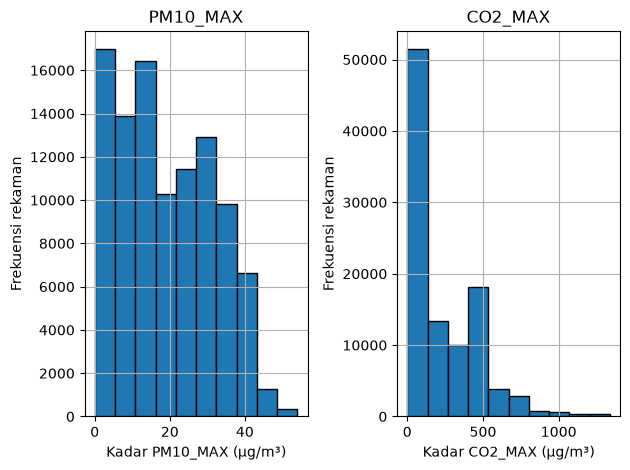



Persebaran data PM10_MAX dan CO2_MAX cenderung miring ke kanan





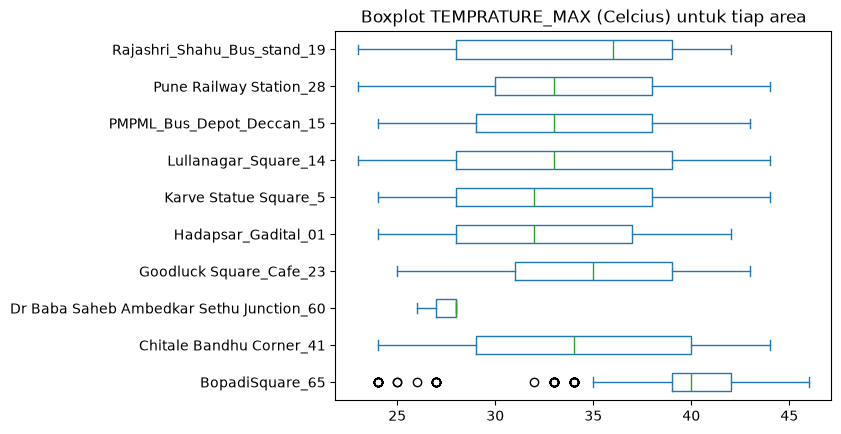



Persebaran data TEMPRATURE_MAX pada tiap area (selain Bopadi Square dan Dr Baba Saheb) cukup simetris.
Pada Area Bopadi Square terlihat beberapa pencilan





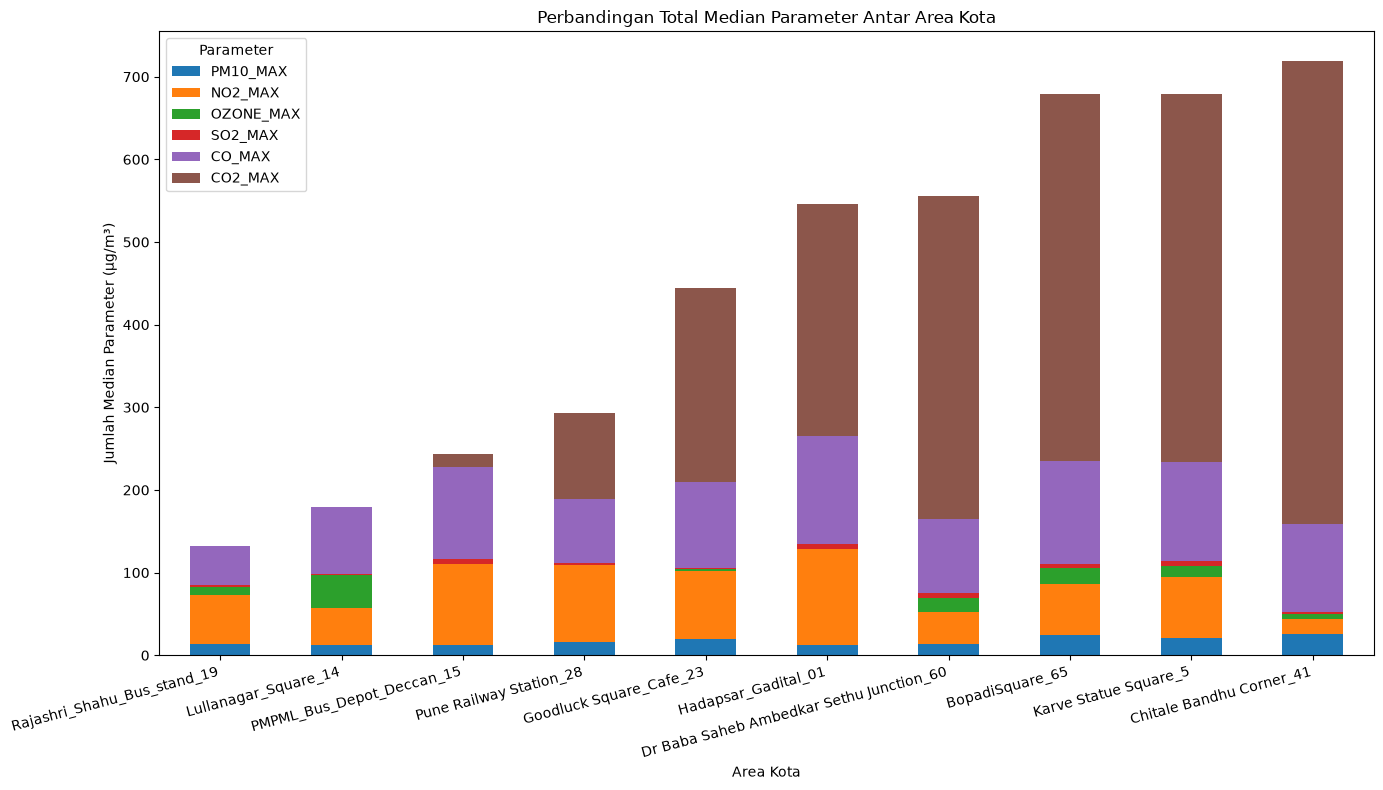



Chitale Bandhu Corner adalah area dengan akumulasi polutan terbanyak berdasarkan pengurutan median tiap parameter


In [37]:
# Visualisasi data
# Minimal buat grafik berikut:
# Setiap grafik wajib punya judul, label sumbu beserta satuan, dan 1–2 kalimat interpretasi di bawahnya.
# Histogram untuk minimal 2 kolom numerik. Jelaskan bentuk sebarannya: simetris, miring ke kanan, atau miring ke kiri.
import matplotlib.pyplot as plt

ax = df[["PM10_MAX", "CO2_MAX"]].hist(edgecolor='black') # Menamai ax sebagai histogram (PM10_MAX dan CO2_MAX) untuk penyingkatan agar memudahkan penggantian nama axis
ax[0, 0].set_xlabel('Kadar PM10_MAX (µg/m³)') # Mengedit nama x-axis untuk grafik histogram yang pertama
ax[0, 0].set_ylabel('Frekuensi rekaman') # Mengedit nama y-axis untuk grafik histogram yang pertama
ax[0, 1].set_xlabel('Kadar CO2_MAX (µg/m³)') # Mengedit nama x-axis untuk grafik histogram yang kedua
ax[0, 1].set_ylabel('Frekuensi rekaman') # # Mengedit nama y-axis untuk grafik histogram yang kedua
plt.tight_layout() # Memastikan tidak ada elemen yang saling menimpa
plt.show()
print("\n\nPersebaran data PM10_MAX dan CO2_MAX cenderung miring ke kanan\n\n\n")


# Boxplot untuk minimal 1 kolom numerik. Tunjukkan apakah ada pencilan menurut aturan 1,5 × IQR.
df.plot.box(by='NAME', column=['TEMPRATURE_MAX'], grid=False, vert=False)
plt.title("Boxplot TEMPRATURE_MAX (Celcius) untuk tiap area") # Mengganti title grafik
plt.show()
print("\n\nPersebaran data TEMPRATURE_MAX pada tiap area (selain Bopadi Square dan Dr Baba Saheb) cukup simetris.\nPada Area Bopadi Square terlihat beberapa pencilan\n\n\n")


# Diagram batang untuk minimal 1 kolom kategorik.
import matplotlib.pyplot as plt
import seaborn as sns
# Hitung median untuk setiap variabel per area kota
median_per_kota = df.groupby("NAME")[["PM10_MAX", "NO2_MAX", "OZONE_MAX", "SO2_MAX", "CO_MAX", "CO2_MAX"]].median()

median_per_kota["TOTAL"] = median_per_kota.sum(axis=1) # Membuat kolom baru bernama TOTAL yang berisikan penjumlahan semua median variabel per area kota, sum(axis=1) artinya menjumlahkan secara horizontal

median_per_kota = median_per_kota.sort_values( # Menyortir urutan baris berdasarkan nilai di kolom TOTAL
    by="TOTAL"
)

median_per_kota.drop(  # drop(columns="TOTAL") menghapus kolom Total agar tidak muncul di grafik yang akan ditampilkan
    columns="TOTAL"
).plot(                # plot() Membuat grafik dengan kriteria "bar"
    kind="bar",        # kind="bar" mengatur jenis grafik batang
    stacked=True,      # Batang parameter tiap kategori area ditumpuk
    figsize=(14,8)     # ukuran kanvas grafik (width, height)
)

plt.title("Perbandingan Total Median Parameter Antar Area Kota") # Mengatur judul diagram batang
plt.xlabel("Area Kota")                                          # xlabel() mengatur judul label pada sumbu x
plt.ylabel("Jumlah Median Parameter (µg/m³)")                    # ylabel() mengatur judul label pada sumbu y

plt.legend(                     # Menampilkan pewarnaan yang berbeda pada bar nilai median yang digabung
    title="Parameter",          # Menamai judul keterangan dengan "Parameter"
    loc="upper left"            # Mengatur lokasi keterangan di posisi kiri atas grafik
)

plt.xticks(      # xticks() mengatur hal terkait posisi label pada sumbu x
    rotation=15,     # rotation mengatur putaran tiap label agar dapat tampil dengan sudut kemiringan tertentu
    ha='right'       # mengatur Horizontal Alignment agar ujung kanan label sejajar dengan batangannya
)

plt.tight_layout() # Memastikan tidak ada elemen yang saling menimpa
plt.show()

print("\n\nChitale Bandhu Corner adalah area dengan akumulasi polutan terbanyak berdasarkan pengurutan median tiap parameter")

# Kesimpulan
Jawab setiap pertanyaan dari sel 2 dengan angka hasil analisis:
1. Area "Chitale Bandhu Corner" adalah area dengan akumulasi median kadar polutan terbanyak di antara sampel area lain.
2. Di Chitale Bandhu Corner, polutan dominannya adalah CO2.


Tuliskan 3–5 temuan paling menarik:
1. Pada mayoritas area (7 dari 10), jenis polutan yang mendominasi adalah CO2.
2. Rajashri Shahu Bus Stand merupakan area dengan kadar polutan paling rendah dari sampel area lain, walau merupakan area transit Bus.
3. Berdasarkan grafik boxplot, didapatkan bahwa TEMPRATURE_MAX di area Bopadi Square lebih tinggi dari pada Area Chitale, ini menunjukkan bahwa kota dengan kadar polutan yang paling banyak (Chitale Bandhu Corner) belum tentu menjadi area yang paling panas dibanding yang lain.

Sebutkan keterbatasan data, misalnya periode yang pendek atau banyak data kosong:
Jumlah data yang tidak merata pada tiap area di kota pune dapat membuat data cenderung underfitting pada area yang datanya sedikit. Sebagai contoh, data area "Dr Baba Saheb Ambedkar Sethu Junction_60" Hanya mengisi 0.4% dataset, amat rendah dibandingkan data lain yang mencapai persentase 12%

Tuliskan ide pertanyaan lanjutan yang ingin kalian analisis nanti:
1. Apakah ada kaitan antara waktu pengamatan dan kadar polutan yang teramati?
2. Jika ada korelasi yang cukup besar,pada bulan apa area "Chitale Bandhu Corner" cenderung banyak polutannya?

Cantumkan sumber dataset dan referensi belajar. Kalau memakai AI untuk belajar, catat penggunaannya dalam tabel berikut. Mencatat dengan jujur tidak mengurangi nilai.
sumber dataset: Kaggle https://www.kaggle.com/datasets/akshman/pune-smartcity-test-dataset
# Referensi belajar
Cara membuat histogram: https://www.geeksforgeeks.org/python/how-to-create-a-histogram-from-pandas-dataframe/ ===> df.hist() secara sederhana

Modifikasi histogram: https://www.statology.org/pandas-histogram-x-axis-range/ ===> edgecolor='black'

Cara membuat boxplot: https://www.geeksforgeeks.org/pandas/box-plot-visualization-with-pandas-and-seaborn/ ===> df.boxplot() secara sederhana

Argumen fungsi boxplot di pandas: https://www.tutorialspoint.com/python_pandas/python_pandas_box_plots.htm ===> Ternyata Boxplot bisa dibikin Horizontal dengan menambah argumen "vert=False"

# Catatan Penggunaan AI
| Alat | Dipakai untuk | Yang kami pelajari |
|------|---------------|--------------------|
| Copilot | Menanyakan implementasi kode dari ide visualisasi yang diinginkan, serta maksud dari kode yang diberikan, menanyakan alasan eror dari kolom.mode() | penampilan histogram dan bar itu menggunakan function berbeda pada library (histogram menggunakan "hist()" bar menggunakan "plot(kind="bar")", tahapan dalam penampilan grafik melalui penyaringan kolom yang akan ditampilkan -> inisiasi pembuatan grafik dengan function tertentu -> pengaturan elemen label/warna/letak -> penampilan grafik dengan plt.show() , "kolom.mode()" Memberikan output lebih dari 1 data (sehingga output berbentuk series) yang menyebabkan error (untuk mengantisipasinya gunakan "iloc[0]" agar hanya mengambil data yang pertama pada series) |
| Gemini | Menanyakan cara membuat tabel di sel markdown jupyter notebook, memodifikasi keterangan x-axis dan y-axis, menambahkan baris tambahan pada tabel df.describe() | dilakukan dengan kombinasi berpola pada character tertentu, dilakukan dengan method set_xlabel(), dilakukan dengan print pd.concat([df describe], [baris tambahan dalam bentuk pd.DataFrame]) |